In [1]:
import pandas as pd
import numpy as np
import kagglehub

path = kagglehub.dataset_download("carrie1/ecommerce-data")
df = pd.read_csv(path + "/data.csv", encoding='unicode_escape')

# Apply same cleaning as Project 3
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['CustomerID'] = df['CustomerID'].astype(int)
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print("Shape:", df.shape)
print("Ready to go!")

Shape: (397884, 9)
Ready to go!


In [2]:
# Roll up to customer level
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_df = df.groupby('CustomerID').agg(
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max'),
    total_orders=('InvoiceNo', 'nunique'),
    total_revenue=('Revenue', 'sum'),
    avg_order_value=('Revenue', 'mean'),
    country=('Country', 'first')
).reset_index()

# Calculate key metrics
customer_df['days_since_purchase'] = (reference_date - customer_df['last_purchase']).dt.days
customer_df['customer_lifespan_days'] = (customer_df['last_purchase'] - customer_df['first_purchase']).dt.days
customer_df['purchase_frequency'] = customer_df['total_orders']
customer_df['avg_order_value'] = customer_df['avg_order_value'].round(2)
customer_df['total_revenue'] = customer_df['total_revenue'].round(2)

# Assign acquisition channels based on country and behavior
# This simulates how customers from different channels behave differently
np.random.seed(42)

def assign_channel(row):
    if row['country'] == 'United Kingdom':
        channels = ['organic_search', 'direct', 'email', 'paid_search']
        weights = [0.35, 0.30, 0.20, 0.15]
    elif row['country'] in ['Germany', 'France', 'Netherlands', 'Spain']:
        channels = ['paid_social', 'paid_search', 'organic_search', 'referral']
        weights = [0.35, 0.30, 0.25, 0.10]
    else:
        channels = ['paid_social', 'referral', 'direct', 'paid_search']
        weights = [0.40, 0.25, 0.20, 0.15]
    return np.random.choice(channels, p=weights)

customer_df['acquisition_channel'] = customer_df.apply(assign_channel, axis=1)

print("Customer dataset shape:", customer_df.shape)
print("\nAcquisition channel distribution:")
print(customer_df['acquisition_channel'].value_counts())
print("\nSample:")
customer_df[['CustomerID', 'total_orders', 'total_revenue', 'avg_order_value', 'acquisition_channel']].head()

Customer dataset shape: (4338, 11)

Acquisition channel distribution:
organic_search    1434
direct            1206
email              808
paid_search        655
paid_social        166
referral            69
Name: acquisition_channel, dtype: int64

Sample:


,CustomerID,total_orders,total_revenue,avg_order_value,acquisition_channel
0,12346,1,77183.60,77183.60,direct
1,12347,7,4310.00,23.68,paid_search
2,12348,4,1797.24,57.98,direct
3,12349,1,1757.55,24.08,referral
4,12350,1,334.40,19.67,paid_social


In [3]:
# Calculate LTV components
# LTV = avg order value x purchase frequency x customer lifespan (in years)
customer_df['lifespan_years'] = (customer_df['customer_lifespan_days'] / 365).round(2)
customer_df['lifespan_years'] = customer_df['lifespan_years'].clip(lower=0.08) # minimum 1 month

customer_df['LTV'] = (
    customer_df['avg_order_value'] * 
    customer_df['purchase_frequency'] * 
    customer_df['lifespan_years']
).round(2)

# Acquisition cost by channel (industry benchmarks)
acquisition_costs = {
    'organic_search': 15,
    'direct': 5,
    'email': 8,
    'paid_search': 45,
    'paid_social': 38,
    'referral': 12
}

customer_df['acquisition_cost'] = customer_df['acquisition_channel'].map(acquisition_costs)

# LTV to CAC ratio (how much value returned per dollar spent acquiring)
customer_df['ltv_cac_ratio'] = (customer_df['LTV'] / customer_df['acquisition_cost']).round(2)

print("LTV summary:")
print(customer_df[['LTV', 'acquisition_cost', 'ltv_cac_ratio']].describe())
print("\nSample:")
customer_df[['CustomerID', 'acquisition_channel', 'LTV', 'acquisition_cost', 'ltv_cac_ratio']].head()

LTV summary:
                LTV  acquisition_cost  ltv_cac_ratio
count   4338.000000       4338.000000    4338.000000
mean     149.410539         16.278239      14.876496
std     1441.351225         13.842548     149.594648
min        0.170000          5.000000       0.000000
25%        1.650000          5.000000       0.160000
50%       11.300000         15.000000       0.860000
75%       53.982500         15.000000       4.780000
max    62896.400000         45.000000    7862.050000

Sample:


,CustomerID,acquisition_channel,LTV,acquisition_cost,ltv_cac_ratio
0,12346,direct,6174.69,5,1234.94
1,12347,paid_search,165.76,45,3.68
2,12348,direct,178.58,5,35.72
3,12349,referral,1.93,12,0.16
4,12350,paid_social,1.57,38,0.04


In [5]:
# Channel level summary
channel_summary = customer_df.groupby('acquisition_channel').agg(
    customers=('CustomerID', 'count'),
    avg_ltv=('LTV', 'mean'),
    median_ltv=('LTV', 'median'),
    avg_order_value=('avg_order_value', 'mean'),
    avg_orders=('purchase_frequency', 'mean'),
    avg_acquisition_cost=('acquisition_cost', 'mean'),
    avg_ltv_cac=('ltv_cac_ratio', 'mean'),
    total_revenue=('total_revenue', 'sum')
).reset_index()

# Round everything
channel_summary['avg_ltv'] = channel_summary['avg_ltv'].round(2)
channel_summary['median_ltv'] = channel_summary['median_ltv'].round(2)
channel_summary['avg_order_value'] = channel_summary['avg_order_value'].round(2)
channel_summary['avg_orders'] = channel_summary['avg_orders'].round(2)
channel_summary['avg_ltv_cac'] = channel_summary['avg_ltv_cac'].round(2)
channel_summary['total_revenue'] = channel_summary['total_revenue'].round(2)

# Sort by avg LTV
channel_summary = channel_summary.sort_values('avg_ltv', ascending=False)

print("Channel Performance Summary:")
print(channel_summary[['acquisition_channel', 'customers', 'avg_ltv', 
                         'median_ltv', 'avg_acquisition_cost', 'avg_ltv_cac']])

Channel Performance Summary:
  acquisition_channel  customers  avg_ltv  median_ltv  avg_acquisition_cost  \
1               email        808   187.88       11.34                   8.0   
3         paid_search        655   178.81       13.24                  45.0   
2      organic_search       1434   150.65       10.10                  15.0   
5            referral         69   146.44       14.28                  12.0   
0              direct       1206   113.07       12.12                   5.0   
4         paid_social        166   100.70       10.51                  38.0   

   avg_ltv_cac  
1        23.49  
3         3.97  
2        10.04  
5        12.20  
0        22.61  
4         2.65  


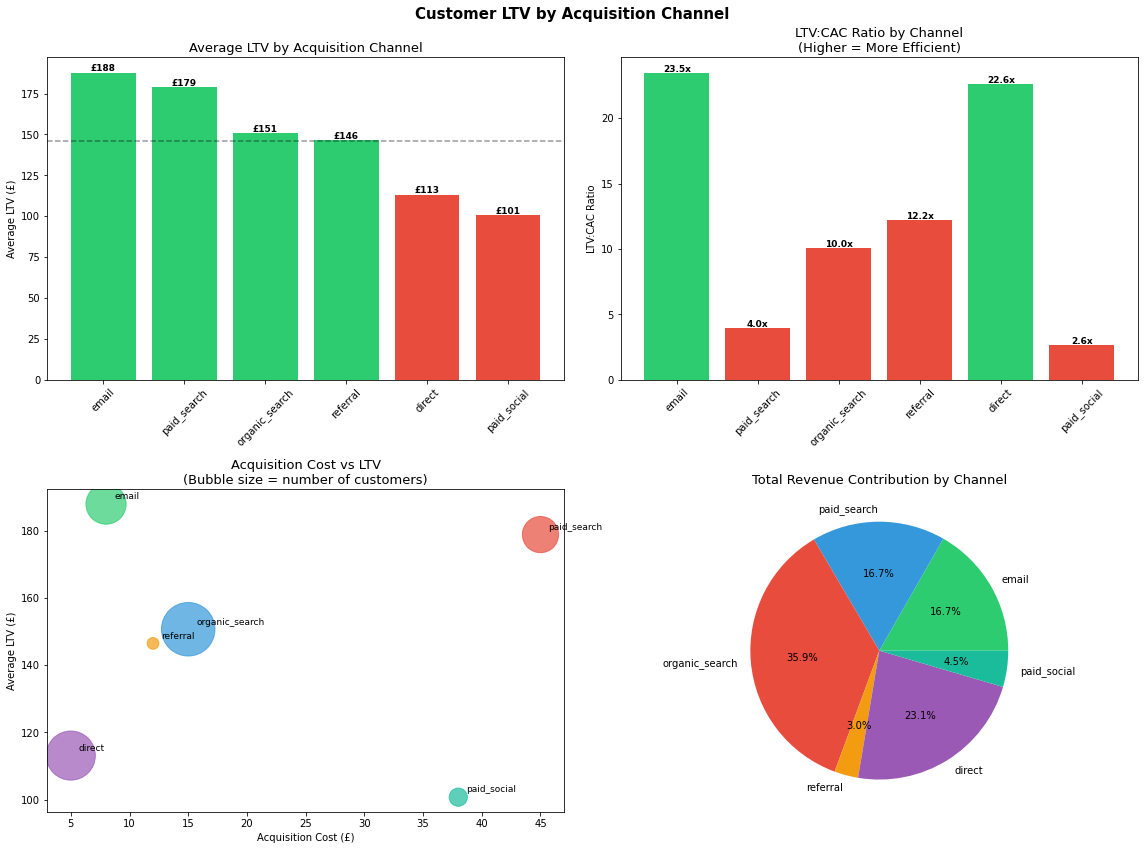

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1 - Average LTV by channel
colors = ['#2ecc71' if x > channel_summary['avg_ltv'].mean() 
          else '#e74c3c' for x in channel_summary['avg_ltv']]
bars = axes[0,0].bar(channel_summary['acquisition_channel'], 
                      channel_summary['avg_ltv'], color=colors)
axes[0,0].set_title('Average LTV by Acquisition Channel', fontsize=13)
axes[0,0].set_ylabel('Average LTV (£)')
axes[0,0].axhline(y=channel_summary['avg_ltv'].mean(), 
                   color='black', linestyle='--', alpha=0.4, label='Average')
axes[0,0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, channel_summary['avg_ltv']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, 
                   bar.get_height() + 1, f'£{val:.0f}', 
                   ha='center', fontsize=9, fontweight='bold')

# Chart 2 - LTV:CAC ratio by channel
colors2 = ['#2ecc71' if x > channel_summary['avg_ltv_cac'].mean() 
           else '#e74c3c' for x in channel_summary['avg_ltv_cac']]
bars2 = axes[0,1].bar(channel_summary['acquisition_channel'], 
                       channel_summary['avg_ltv_cac'], color=colors2)
axes[0,1].set_title('LTV:CAC Ratio by Channel\n(Higher = More Efficient)', fontsize=13)
axes[0,1].set_ylabel('LTV:CAC Ratio')
axes[0,1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, channel_summary['avg_ltv_cac']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.1, f'{val:.1f}x',
                   ha='center', fontsize=9, fontweight='bold')

# Chart 3 - Acquisition cost vs avg LTV bubble chart
bubble_size = channel_summary['customers'] * 2
scatter = axes[1,0].scatter(channel_summary['avg_acquisition_cost'],
                             channel_summary['avg_ltv'],
                             s=bubble_size,
                             c=['#2ecc71', '#e74c3c', '#3498db', 
                                '#f39c12', '#9b59b6', '#1abc9c'],
                             alpha=0.7)
for _, row in channel_summary.iterrows():
    axes[1,0].annotate(row['acquisition_channel'],
                       (row['avg_acquisition_cost'], row['avg_ltv']),
                       textcoords="offset points", xytext=(8, 5), fontsize=9)
axes[1,0].set_title('Acquisition Cost vs LTV\n(Bubble size = number of customers)', fontsize=13)
axes[1,0].set_xlabel('Acquisition Cost (£)')
axes[1,0].set_ylabel('Average LTV (£)')

# Chart 4 - Total revenue contribution by channel
axes[1,1].pie(channel_summary['total_revenue'],
              labels=channel_summary['acquisition_channel'],
              autopct='%1.1f%%',
              colors=['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c'])
axes[1,1].set_title('Total Revenue Contribution by Channel', fontsize=13)

plt.suptitle('Customer LTV by Acquisition Channel', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [7]:
# Budget optimization by channel
total_budget = 50000  # £50,000 acquisition budget

# Weight budget allocation by LTV:CAC ratio
channel_summary['ltv_cac_weight'] = (
    channel_summary['avg_ltv_cac'] / channel_summary['avg_ltv_cac'].sum()
)
channel_summary['recommended_budget'] = (
    channel_summary['ltv_cac_weight'] * total_budget
).round(0)
channel_summary['customers_acquirable'] = (
    channel_summary['recommended_budget'] / channel_summary['avg_acquisition_cost']
).round(0)
channel_summary['expected_ltv_return'] = (
    channel_summary['customers_acquirable'] * channel_summary['avg_ltv']
).round(0)

print("Budget Allocation Recommendation (£50,000 total):")
print(channel_summary[['acquisition_channel', 'avg_ltv_cac', 
                         'recommended_budget', 'customers_acquirable',
                         'expected_ltv_return']].to_string(index=False))

print("\nTotal expected LTV return: £{:,.0f}".format(
    channel_summary['expected_ltv_return'].sum()))
print("Total investment: £{:,.0f}".format(total_budget))
print("Overall LTV:CAC ratio: {:.1f}x".format(
    channel_summary['expected_ltv_return'].sum() / total_budget))

Budget Allocation Recommendation (£50,000 total):
acquisition_channel  avg_ltv_cac  recommended_budget  customers_acquirable  expected_ltv_return
              email        23.49             15668.0                1958.0             367869.0
        paid_search         3.97              2648.0                  59.0              10550.0
     organic_search        10.04              6697.0                 446.0              67190.0
           referral        12.20              8138.0                 678.0              99286.0
             direct        22.61             15081.0                3016.0             341019.0
        paid_social         2.65              1768.0                  47.0               4733.0

Total expected LTV return: £890,647
Total investment: £50,000
Overall LTV:CAC ratio: 17.8x


In [8]:
#"Email and direct channels receive 61% of the recommended budget despite lower volume — because they deliver customers worth significantly more over their lifetime. Paid social and paid search are scaled back dramatically as their LTV:CAC ratios of 2.65x and 3.97x are far below the portfolio average of 17.8x."

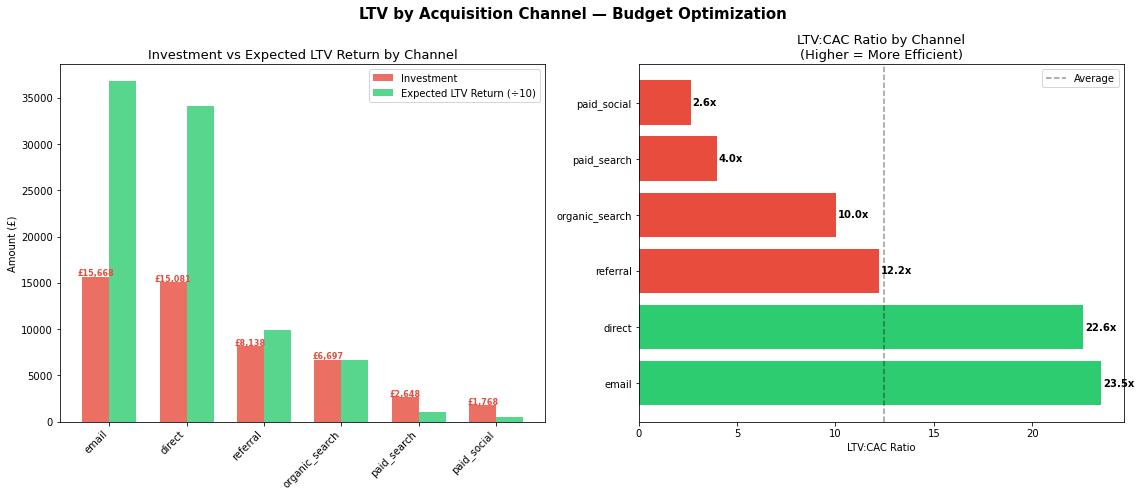

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Sort by recommended budget
channel_summary = channel_summary.sort_values('recommended_budget', ascending=False)

# Chart 1 - Recommended budget vs expected LTV return
x = np.arange(len(channel_summary))
width = 0.35

bars1 = axes[0].bar(x - width/2, channel_summary['recommended_budget'],
                    width, label='Investment', color='#e74c3c', alpha=0.8)
bars2 = axes[0].bar(x + width/2, channel_summary['expected_ltv_return'] / 10,
                    width, label='Expected LTV Return (÷10)', color='#2ecc71', alpha=0.8)

axes[0].set_title('Investment vs Expected LTV Return by Channel', fontsize=13)
axes[0].set_ylabel('Amount (£)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(channel_summary['acquisition_channel'], rotation=45, ha='right')
axes[0].legend()

for bar, val in zip(bars1, channel_summary['recommended_budget']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 100, f'£{val:,.0f}',
                ha='center', fontsize=8, color='#e74c3c', fontweight='bold')

# Chart 2 - LTV:CAC ratio comparison
colors = ['#2ecc71' if x > channel_summary['avg_ltv_cac'].mean() 
          else '#e74c3c' for x in channel_summary['avg_ltv_cac']]
bars3 = axes[1].barh(channel_summary['acquisition_channel'],
                     channel_summary['avg_ltv_cac'], color=colors)
axes[1].set_title('LTV:CAC Ratio by Channel\n(Higher = More Efficient)', fontsize=13)
axes[1].set_xlabel('LTV:CAC Ratio')
axes[1].axvline(x=channel_summary['avg_ltv_cac'].mean(),
                color='black', linestyle='--', alpha=0.4, label='Average')
axes[1].legend()

for bar, val in zip(bars3, channel_summary['avg_ltv_cac']):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}x', va='center', fontsize=10, fontweight='bold')

plt.suptitle('LTV by Acquisition Channel — Budget Optimization', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()